Statistical analysis to view relationship between variables

Importing downloaded file from google drrive

In [ ]:
pip install -- pandas numpy scikit-learn  matplotlib seaborn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = '/content/drive/My Drive/Data Science Projects/customer_data.csv'
df = pd.read_csv(file_path)

print(df.head())


   customer_id        full_name  age age_group  gender        state  \
0      1444270  Customer 444269   27     26-35    Male    Karnataka   
1      1029696   Customer 29695   43     35-50   Other    Telangana   
2      1050871   Customer 50870   24     18-25    Male      Gujarat   
3      1340336  Customer 340335   59       50+  Female  West Bengal   
4      1137281  Customer 137280   54       50+    Male    Telangana   

  signup_date  tenure_months  tenure_group membership_tier  ...  \
0  2018-08-04            100  Over 3 years          Silver  ...   
1  2018-09-23            104  Over 3 years          Silver  ...   
2  2022-12-16             89  Over 3 years           Basic  ...   
3  2025-02-05            107  Over 3 years          Silver  ...   
4  2021-02-11             33       3 years            Gold  ...   

  days_since_last_login_group email_open_rate tickets_last_year  ticket_group  \
0                  Over 1year            0.33                 8          High   
1       

T-test

In [ ]:
numeric_columns =['total_orders','total_spent','total_returns','lifetime_value',
 'payment_failures','cart_abandon_rate',
 'avg_resolution_hours','age', 'wishlist_items', 'tenure_months','sales']

numeric_cols = [col for col in numeric_columns if col in df.columns]

Correlation between variables

Text(0.5, 1.0, 'Correlation Map')

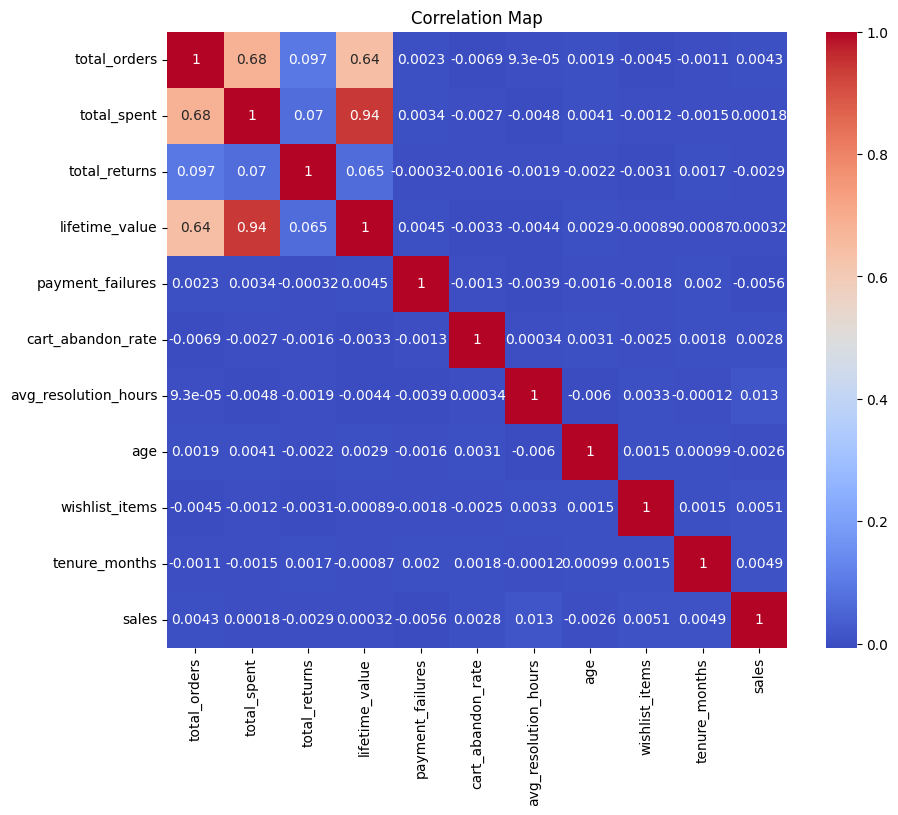

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
correlation_df = df[numeric_cols]
correlation_matrix = correlation_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Map')

Hypothesis Testing

T-test
null hypothesis: There is no significant relationship between lifetime_value and churn
Alternate hypothesis: There is significant relationship between lifetime_value and churn

In [ ]:
from scipy.stats import ttest_ind
alpha =0.05
churn_yes = df[df['churn'] == True]['lifetime_value']
churn_no = df[df['churn'] == False]['lifetime_value']

t_statistic, p_value = ttest_ind(churn_yes, churn_no)
print("T-statistic:", t_statistic)
print("P-value:", p_value)
if (p_value < alpha):
    print("Reject null hypothesis: There is significant relationship between churn and life time value")
else:
    print("Fail to reject null hypothesis: There is no significant relationship between churn and lifetime_value")

T-statistic: -76.88692996110775
P-value: 0.0
Reject null hypothesis: There is significant relationship between churn and life time value


In [ ]:
from scipy.stats import ttest_ind
alpha =0.05
churn_yes = df[df['churn'] == True]['total_orders']
churn_no = df[df['churn'] == False]['total_orders']

t_statistic, p_value = ttest_ind(churn_yes, churn_no)
print("T-statistic:", t_statistic)
print("P-value:", p_value)
if (p_value < alpha):
    print("Reject null hypothesis: There is significant relationship between churn and life total_orders")
else:
    print("Fail to reject null hypothesis: There is no significant relationship between churn and total_orders")

T-statistic: -122.39964659041847
P-value: 0.0
Reject null hypothesis: There is significant relationship between churn and life total_orders


In [ ]:
from scipy.stats import ttest_ind
alpha =0.05
churn_yes = df[df['churn'] == True]['total_returns']
churn_no = df[df['churn'] == False]['total_returns']

t_statistic, p_value = ttest_ind(churn_yes, churn_no)
print("T-statistic:", t_statistic)
print("P-value:", p_value)
if (p_value < alpha):
    print("Reject null hypothesis: There is significant relationship between churn and total returns")
else:
    print("Fail to reject null hypothesis: There is no significant relationship between churn and total_returns")

T-statistic: 42.483154963121315
P-value: 0.0
Reject null hypothesis: There is significant relationship between churn and total returns


In [ ]:
from scipy.stats import ttest_ind
alpha =0.05
churn_yes = df[df['churn'] == True]['total_spent']
churn_no = df[df['churn'] == False]['total_spent']

t_statistic, p_value = ttest_ind(churn_yes, churn_no)
print("T-statistic:", t_statistic)
print("P-value:", p_value)
if (p_value < alpha):
    print("Reject null hypothesis: There is significant relationship between churn and total spent")
else:
    print("Fail to reject null hypothesis: There is no significant relationship between churn and total_ spent")

T-statistic: -81.61612282390129
P-value: 0.0
Reject null hypothesis: There is significant relationship between churn and total spent


In [ ]:
from scipy.stats import ttest_ind
alpha =0.05
churn_yes = df[df['churn'] == True]['average_monthly_spend']
churn_no = df[df['churn'] == False]['average_monthly_spend']

t_statistic, p_value = ttest_ind(churn_yes, churn_no)
print("T-statistic:", t_statistic)
print("P-value:", p_value)
if (p_value < alpha):
    print("Reject null hypothesis: There is significant relationship between churn and average_monthly_spent")
else:
    print("Fail to reject null hypothesis: There is no significant relationship between churn and average_monthly_spent")

T-statistic: -1.2053617348727512
P-value: 0.2280662001111514
Fail to reject null hypothesis: There is no significant relationship between churn and average_monthly_spent


In [ ]:
from scipy.stats import ttest_ind
alpha =0.05
churn_yes = df[df['churn'] == True]['wishlist_items']
churn_no = df[df['churn'] == False]['wishlist_items']

t_statistic, p_value = ttest_ind(churn_yes, churn_no)
print("T-statistic:", t_statistic)
print("P-value:", p_value)
if (p_value < alpha):
    print("Reject null hypothesis: There is significant relationship between churn and wishlist_items")
else:
    print("Fail to reject null hypothesis: There is no significant relationship between churn and wishlist_items")

T-statistic: 0.8462799413253435
P-value: 0.3973983795117406
Fail to reject null hypothesis: There is no significant relationship between churn and wishlist_items


Checking statistical relationship between categorical variables and churn by vbuildin contigency table and chi-square

In [ ]:
#contigency table between
from scipy.stats import chi2_contingency
contingency_table_age = pd.crosstab(df['age_group'], df['churn'])
ch1, p_value, dof, expected = chi2_contingency(contingency_table_age)
print("Chi-square statistic:", ch1)
print("P-value:", p_value)
if (p_value < alpha):
    print("Reject null hypothesis: There is significant relationship between age group and churn")
else:
    print("Fail to reject null hypothesis: There is no significant relationship between age group and churn")


Chi-square statistic: 1.3327632528565212
P-value: 0.7213682092476499
Fail to reject null hypothesis: There is no significant relationship between age group and churn


In [ ]:
#contigency table between
from scipy.stats import chi2_contingency
contingency_table_membership = pd.crosstab(df['membership_tier'], df['churn'])
ch1, p_value, dof, expected = chi2_contingency(contingency_table_age)
print("Chi-square statistic:", ch1)
print("P-value:", p_value)
if (p_value < alpha):
    print("Reject null hypothesis: There is significant relationship between membership tier and churn")
else:
    print("Fail to reject null hypothesis: There is no significant relationship between membership tier and churn")


Chi-square statistic: 1.3327632528565212
P-value: 0.7213682092476499
Fail to reject null hypothesis: There is no significant relationship between membership tier and churn


In [ ]:
#contigency table between
from scipy.stats import chi2_contingency
contingency_table_product = pd.crosstab(df['product_category'], df['churn'])
ch1, p_value, dof, expected = chi2_contingency(contingency_table_product)
print("Chi-square statistic:", ch1)
print("P-value:", p_value)
if (p_value < alpha):
    print("Reject null hypothesis: There is significant relationship between product category and churn")
else:
    print("Fail to reject null hypothesis: There is no significant relationship between product category and churn")


Chi-square statistic: 0.9589170508612602
P-value: 0.9159601993038454
Fail to reject null hypothesis: There is no significant relationship between product category and churn


In [ ]:
#contigency table between churn and payment method
from scipy.stats import chi2_contingency
contingency_table_payment = pd.crosstab(df['payment_method'], df['churn'])
ch1, p_value, dof, expected = chi2_contingency(contingency_table_payment)
print("Chi-square statistic:", ch1)
print("P-value:", p_value)
if (p_value < alpha):
    print("Reject null hypothesis: There is significant relationship between payment method and churn")
else:
    print("Fail to reject null hypothesis: There is no significant relationship between payment method and churn")


Chi-square statistic: 2.8602441171990467
P-value: 0.7215214792359843
Fail to reject null hypothesis: There is no significant relationship between payment method and churn


The next step is feature selction using factor analyser. Check the project folder to view